In [7]:
import torch

def generate_base_sparsity_mask(max_seqlen_q, max_seqlen_k, round_base, m_block_dim, n_block_dim, sparsity, causal=False, device="cuda"):
    def round_to_multiple(x, base):
        return ((x + base - 1) // base) * base
        
    nrow = round_to_multiple(max_seqlen_q, round_base) // m_block_dim
    ncol = round_to_multiple(max_seqlen_k, round_base) // n_block_dim
    base_mask = torch.zeros(1, nrow, ncol, device=device, dtype=torch.bool)
    
    density = 1.0 - sparsity
    if 0.0 < density < 1.0:
        for i in range(nrow): 
            idx = nrow - i - 1
            if causal:
                available_col_num = max(0, ncol - i)
                num_one = max(1, int(density * available_col_num))
                if available_col_num > 0:
                    base_mask[0][idx, torch.randperm(available_col_num)[:num_one]] = True
            else:
                available_col_num = ncol
                num_one = max(1, int(density * available_col_num))
                base_mask[0][idx, torch.randperm(available_col_num)[:num_one]] = True
    elif density == 1.0:
        base_mask[0] = torch.ones_like(base_mask[0])
    
    calculated_block_num = base_mask.sum().item()
    total_block_num = 0
    if causal:
        for i in range(nrow):
             total_block_num += max(0, ncol - i)
    else:
        total_block_num = nrow * ncol
        
    real_sparsity = 1.0 - (calculated_block_num / total_block_num) if total_block_num > 0 else 0.0
    return base_mask, real_sparsity

In [13]:
BLOCK_SIZE = 128
base_blockmask, real_sparsity = generate_base_sparsity_mask(
    4096, 4096, BLOCK_SIZE, BLOCK_SIZE, BLOCK_SIZE, 
    sparsity=0.2, causal=False, device='cuda'
)

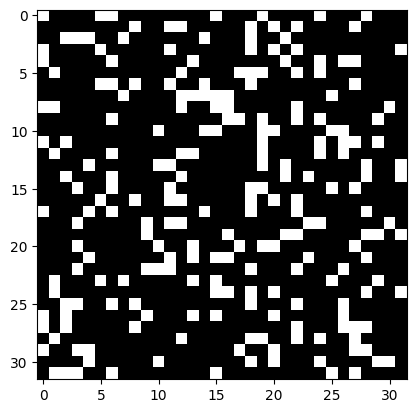

In [14]:
import matplotlib.pyplot as plt
plt.imshow(base_blockmask[0].cpu(), cmap='gray_r')